<a href="https://colab.research.google.com/github/aliraza0321/neurofive-solutions-ML-internship/blob/main/Task_4_Predict_House_Price_using_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
#import all necessary items and data set
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
#fetch data set and EDA our data using head and shape
california = fetch_california_housing(as_frame=True)
df = california.frame
print(df.head())
print(df.shape)


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)


In [19]:
#remove all extra details and only has important features

extra_columns=['MedHouseVal','AveOccup','Population']
X = df.drop(extra_columns, axis=1)
y = df['MedHouseVal']
print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Latitude  Longitude
0  8.3252      41.0  6.984127   1.023810     37.88    -122.23
1  8.3014      21.0  6.238137   0.971880     37.86    -122.22
2  7.2574      52.0  8.288136   1.073446     37.85    -122.24
3  5.6431      52.0  5.817352   1.073059     37.85    -122.25
4  3.8462      52.0  6.281853   1.081081     37.85    -122.25
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [21]:
#split our dataset in appropriate technique
x_train,x_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
    )


In [22]:
#rescale our data at same scale
scaler=StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [23]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [24]:
pred=model.predict(x_test)#predictions

In [25]:
#evaluate our model using r2score and root mean square error
r2Score=r2_score(y_test,pred)
print("R2 score is ",r2Score)
rootMeanSquaredError=np.sqrt(mean_squared_error(y_test,pred))
print("Root Mean Squared Error is ",r2Score)
"""
R2 Score (0.575): The model explains 57.5% of the variance in house prices.
This indicates moderate/average predictive power, meaning there is still 42.5%
of the data's variation that the model is missing.
RMSE (0.575):The average prediction error is ~$57,500.
 On average, the model's predictions miss the actual house price by this amount.
 """

R2 score is  0.5749693819995386
Root Mean Squared Error is  0.5749693819995386


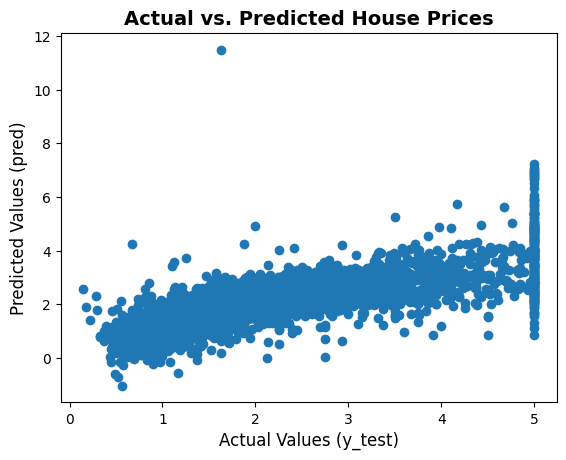

In [34]:
plt.scatter(y_test, pred)
plt.title('Actual vs. Predicted House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Values (y_test)', fontsize=12)
plt.ylabel('Predicted Values (pred)', fontsize=12)
plt.show()
#show our predicitons and actual values usign scatter plot